# ДЗ 2. Имплементация GAN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
from torchvision.datasets import ImageFolder

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

data_path = '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba'

dataset = ImageFolder(root=data_path, transform=transform)

# dataset = datasets.CelebA(root="/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba", download=False, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

In [3]:
class CSPup(nn.Module):
    def __init__(self, in_ch: int, out_ch: int | None = None):
        super().__init__()
        out_ch = out_ch if out_ch is not None else in_ch // 2
        half   = out_ch
        self.split_left  = nn.Conv2d(in_ch, half, 1, bias=False)
        self.split_right = nn.Conv2d(in_ch, half, 1, bias=False)

        self.left_up = nn.ConvTranspose2d(half, half, 4, 2, 1, bias=False)

        self.right_conv1 = nn.Sequential(
            nn.Conv2d(half, half, 1, bias=False),
            nn.BatchNorm2d(half),
            nn.ReLU(inplace=True))
        self.right_up = nn.ConvTranspose2d(half, half, 4, 2, 1, bias=False)
        self.right_conv3 = nn.Sequential(
            nn.Conv2d(half, half, 3, padding=1, bias=False),
            nn.BatchNorm2d(half),
            nn.ReLU(inplace=True),
            nn.Conv2d(half, half, 3, padding=1, bias=False),
            nn.BatchNorm2d(half))

        self.bn_out = nn.BatchNorm2d(half)
        self.relu   = nn.ReLU(inplace=True)

    def forward(self, x):
        left  = self.left_up(self.split_left(x))
        right = self.split_right(x)
        right = self.right_up(self.right_conv1(right))
        right = self.right_conv3(right)
        return self.relu(self.bn_out(left + right))

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim: int = 100):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 4 * 4 * 1024, bias=False),
            nn.BatchNorm1d(4 * 4 * 1024),
            nn.ReLU(inplace=True))
        self.csp1 = CSPup(1024, 512)
        self.csp2 = CSPup(512, 256)
        self.up3  = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.up4  = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.up5  = nn.Sequential(
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh())
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 1024, 4, 4)
        return self.up5(self.up4(self.up3(self.csp2(self.csp1(x)))))


def _conv_block(in_ch, out_ch, bn=True):
    layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)]
    if bn:
        layers.append(nn.BatchNorm2d(out_ch))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    return nn.Sequential(*layers)


def _critic_block(in_ch, out_ch, first=False):
    layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)]
    if not first:
        layers.append(nn.InstanceNorm2d(out_ch, affine=True))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    return nn.Sequential(*layers)

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            _conv_block(  3,   64, bn=False),
            _conv_block( 64,  128),
            _conv_block(128,  256),
            _conv_block(256,  512),
            _conv_block(512, 1024),
            nn.Conv2d(1024, 1, 4, 1, 0, bias=False),
            nn.Sigmoid())
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        return self.net(x).view(x.size(0), -1)

### Baseline

In [29]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

real_label = 0.9
fake_label = 0.0

G_losses, D_losses = [], []

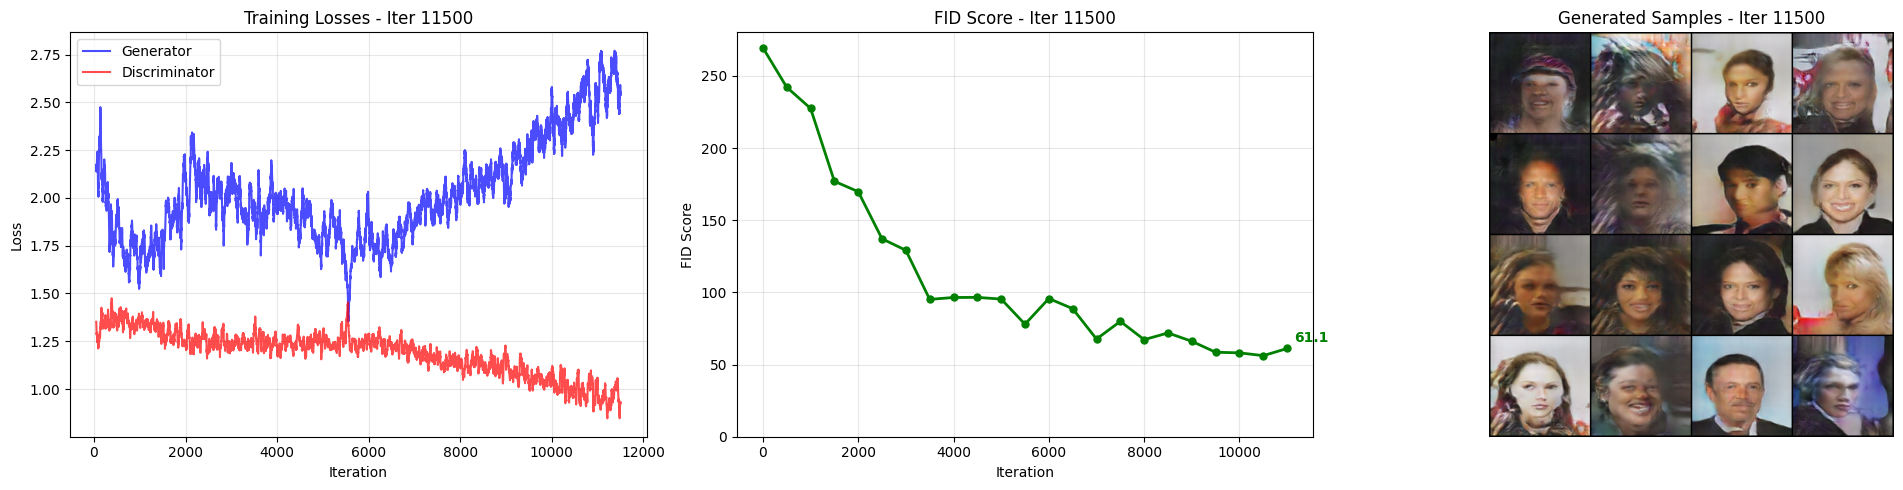

Epoch 4/30:  63%|██████▎   | 2002/3166 [21:52<2:42:01,  8.35s/it, D_loss=0.6777, G_loss=2.4750]

Iteration 11500 | G Loss: 2.4750 | D Loss: 0.6777 | FID: 61.14


KeyboardInterrupt: 

In [32]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from tqdm import tqdm
import numpy as np
from scipy import linalg
import torch.nn.functional as F
from scipy.linalg import sqrtm

def get_inception_model():
    from torchvision.models import inception_v3
    model = inception_v3(pretrained=True, transform_input=False)
    model.fc = nn.Identity()
    model.eval()
    return model.to(device)

def get_features(model, images, batch_size=64):
    features = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size].to(device)
            batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
            feat = model(batch)
            features.append(feat.cpu())
    return torch.cat(features, dim=0)

def calculate_fid(real_features, fake_features):
    if hasattr(real_features, 'cpu'):
        real_features = real_features.detach().cpu().numpy()
    if hasattr(fake_features, 'cpu'):
        fake_features = fake_features.detach().cpu().numpy()
    
    mu1, sigma1 = np.mean(real_features, axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = np.mean(fake_features, axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2)
    
    covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2 * covmean)
    
    return float(fid)

def generate_samples(n=16):
    G.eval()
    with torch.no_grad():
        noise = torch.randn(n, 100, device=device)
        samples = G(noise)
        samples = (samples + 1) / 2
    G.train()
    return samples.cpu()

def plot_training_progress(iteration, g_losses, d_losses, fid_scores, samples):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    window = min(50, len(g_losses))
    if window > 1:
        g_smooth = np.convolve(g_losses, np.ones(window)/window, mode='valid')
        d_smooth = np.convolve(d_losses, np.ones(window)/window, mode='valid')
        x_smooth = np.arange(window-1, len(g_losses))
    else:
        g_smooth = g_losses
        d_smooth = d_losses
        x_smooth = np.arange(len(g_losses))
    
    ax1 = axes[0]
    ax1.plot(x_smooth, g_smooth, 'b-', label='Generator', alpha=0.7)
    ax1.plot(x_smooth, d_smooth, 'r-', label='Discriminator', alpha=0.7)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'Training Losses - Iter {iteration}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[1]
    fid_iters = list(range(0, iteration + 1, 500))
    if len(fid_scores) > 0:
        ax2.plot(fid_iters[:len(fid_scores)], fid_scores, 'g-', linewidth=2, marker='o', markersize=5)
        ax2.annotate(f'{fid_scores[-1]:.1f}', 
                    xy=(fid_iters[len(fid_scores)-1], fid_scores[-1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold', color='green')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('FID Score')
    ax2.set_title(f'FID Score - Iter {iteration}')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(bottom=0)
    
    ax3 = axes[2]
    grid = make_grid(samples, nrow=4, padding=2)
    ax3.imshow(np.transpose(grid, (1, 2, 0)))
    ax3.axis('off')
    ax3.set_title(f'Generated Samples - Iter {iteration}')
    
    plt.tight_layout()
    plt.show()

print("Loading InceptionV3 for FID calculation")
inception_model = get_inception_model()

print("Extracting real image features for FID")
real_images_sample = []
with torch.no_grad():
    for i, (imgs, _) in enumerate(dataloader):
        if i >= 32:
            break
        real_images_sample.append(imgs)
real_images_sample = torch.cat(real_images_sample, dim=0)
real_features = get_features(inception_model, real_images_sample)
print(f"Real features shape: {real_features.shape}")

epochs = 30
G_losses, D_losses, FID_scores = [], [], []
global_iter = 0
plot_interval = 500


for epoch in range(epochs):
    g_loss_total = d_loss_total = 0
    n_batches = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for imgs, _ in pbar:
        imgs = imgs.to(device)
        bs = imgs.size(0)
        
        D.zero_grad()
        noise = torch.randn(bs, 100, device=device)
        fake = G(noise)
        
        d_real = D(imgs)
        d_fake = D(fake.detach())
        
        D_loss = (criterion(d_real, torch.full_like(d_real, real_label)) + 
                  criterion(d_fake, torch.full_like(d_fake, fake_label)))
        D_loss.backward()
        optimizer_D.step()
        
        G.zero_grad()
        d_fake = D(fake)
        G_loss = criterion(d_fake, torch.full_like(d_fake, real_label))
        G_loss.backward()
        optimizer_G.step()
        
        g_loss_total += G_loss.item()
        d_loss_total += D_loss.item()
        n_batches += 1
        global_iter += 1
        
        G_losses.append(G_loss.item())
        D_losses.append(D_loss.item())
        
        pbar.set_postfix({
            'D_loss': f'{D_loss.item():.4f}', 
            'G_loss': f'{G_loss.item():.4f}'
        })
        
        if global_iter % plot_interval == 0:
            with torch.no_grad():
                noise_fid = torch.randn(2000, 100, device=device)
                fake_images = G(noise_fid)
                fake_images = (fake_images + 1) / 2
                fake_features = get_features(inception_model, fake_images)
                fid = calculate_fid(real_features, fake_features)
                FID_scores.append(fid)
                print(f"FID: {fid:.2f}")
            
            samples = generate_samples(16)
            plot_training_progress(global_iter, G_losses, D_losses, FID_scores, samples)
            print(f"Iteration {global_iter} | G Loss: {G_loss.item():.4f} | D Loss: {D_loss.item():.4f} | FID: {fid:.2f}")
    
    print(f"Epoch {epoch+1:02d}/{epochs} completed | Iterations: {global_iter}")

print(f"Final FID: {FID_scores[-1]:.2f}" if FID_scores else "No FID calculated")

### Baseline + scheduler + clipping

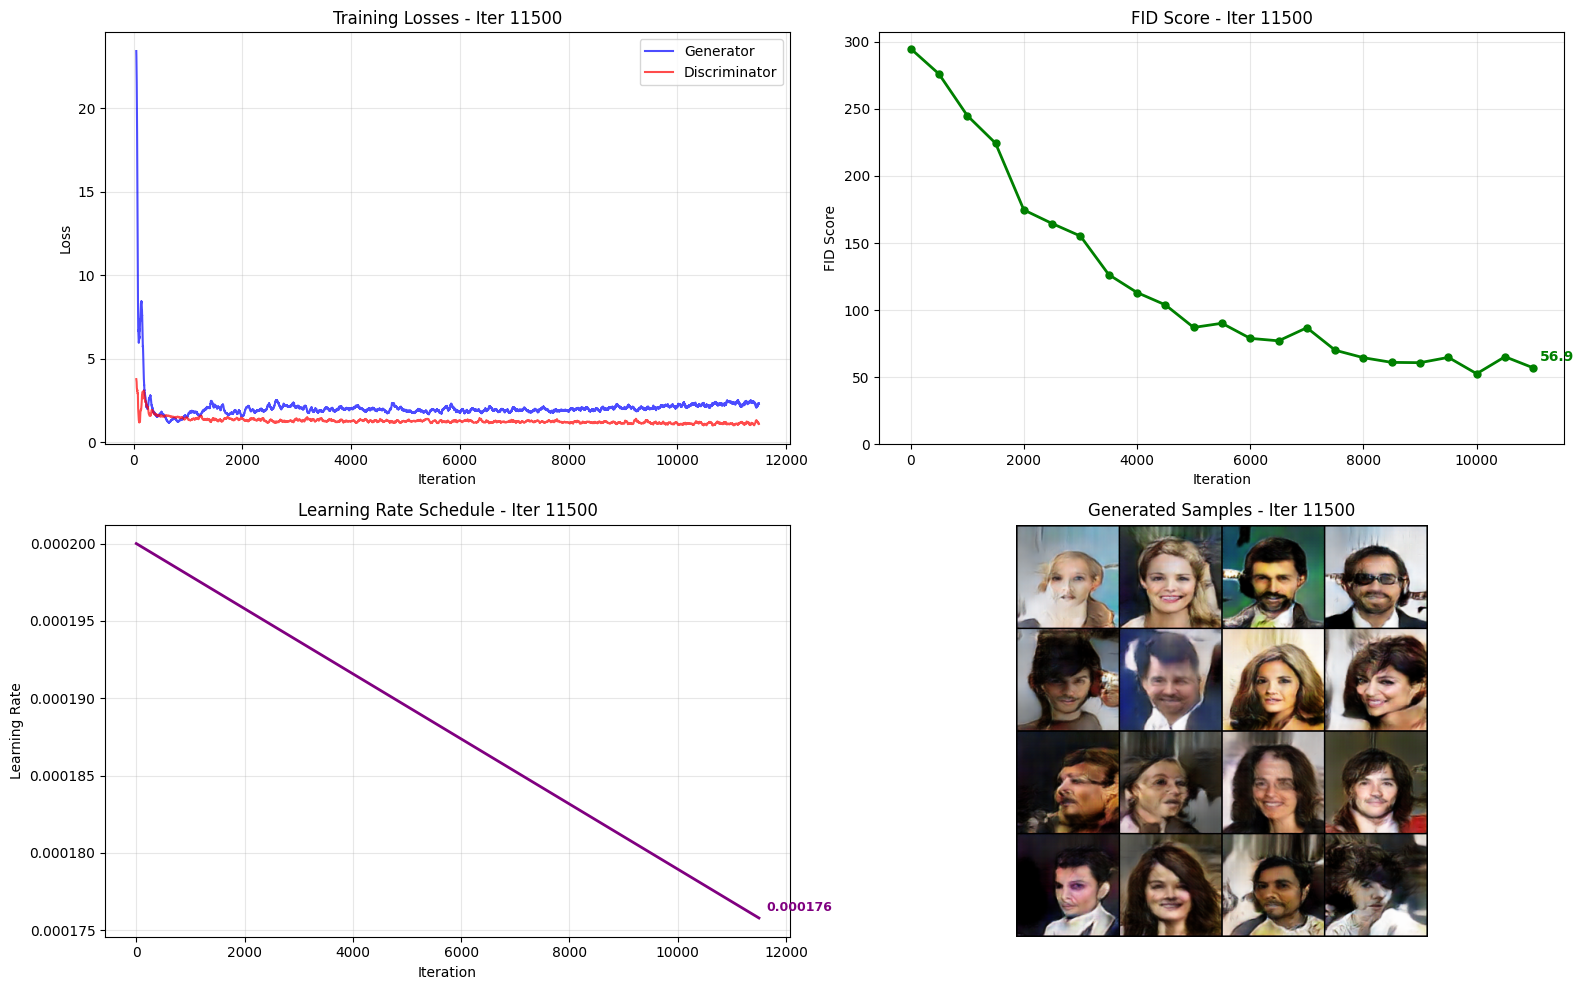

Epoch 4/30:  63%|██████▎   | 2002/3166 [21:55<2:44:52,  8.50s/it, D_loss=0.8374, G_loss=1.9347, lr=0.000176]

Iteration 11500 | G Loss: 1.9347 | D Loss: 0.8374 | FID: 56.92 | LR: 0.000176


KeyboardInterrupt: 

In [35]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

real_label = 0.9
fake_label = 0.0

G_losses, D_losses = [], []

from IPython.display import clear_output
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from tqdm import tqdm
import numpy as np
from scipy import linalg
import torch.nn.functional as F
from scipy.linalg import sqrtm

def get_inception_model():
    from torchvision.models import inception_v3
    model = inception_v3(pretrained=True, transform_input=False)
    model.fc = nn.Identity()
    model.eval()
    return model.to(device)

def get_features(model, images, batch_size=64):
    features = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size].to(device)
            batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
            feat = model(batch)
            features.append(feat.cpu())
    return torch.cat(features, dim=0)

def calculate_fid(real_features, fake_features):
    if hasattr(real_features, 'cpu'):
        real_features = real_features.detach().cpu().numpy()
    if hasattr(fake_features, 'cpu'):
        fake_features = fake_features.detach().cpu().numpy()
    
    mu1, sigma1 = np.mean(real_features, axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = np.mean(fake_features, axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2)
    
    covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2 * covmean)
    
    return float(fid)

def generate_samples(n=16):
    G.eval()
    with torch.no_grad():
        noise = torch.randn(n, 100, device=device)
        samples = G(noise)
        samples = (samples + 1) / 2
    G.train()
    return samples.cpu()

def plot_training_progress(iteration, g_losses, d_losses, fid_scores, samples, lr_history):
    clear_output(wait=True)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    window = min(50, len(g_losses))
    if window > 1:
        g_smooth = np.convolve(g_losses, np.ones(window)/window, mode='valid')
        d_smooth = np.convolve(d_losses, np.ones(window)/window, mode='valid')
        x_smooth = np.arange(window-1, len(g_losses))
    else:
        g_smooth = g_losses
        d_smooth = d_losses
        x_smooth = np.arange(len(g_losses))
    
    ax1 = axes[0, 0]
    ax1.plot(x_smooth, g_smooth, 'b-', label='Generator', alpha=0.7)
    ax1.plot(x_smooth, d_smooth, 'r-', label='Discriminator', alpha=0.7)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'Training Losses - Iter {iteration}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[0, 1]
    fid_iters = list(range(0, iteration + 1, 500))
    if len(fid_scores) > 0:
        ax2.plot(fid_iters[:len(fid_scores)], fid_scores, 'g-', linewidth=2, marker='o', markersize=5)
        ax2.annotate(f'{fid_scores[-1]:.1f}', 
                    xy=(fid_iters[len(fid_scores)-1], fid_scores[-1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold', color='green')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('FID Score')
    ax2.set_title(f'FID Score - Iter {iteration}')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(bottom=0)
    
    ax3 = axes[1, 0]
    ax3.plot(lr_history, 'purple', linewidth=2)
    ax3.set_xlabel('Iteration')
    ax3.set_ylabel('Learning Rate')
    ax3.set_title(f'Learning Rate Schedule - Iter {iteration}')
    ax3.grid(True, alpha=0.3)
    ax3.annotate(f'{lr_history[-1]:.6f}', 
                xy=(len(lr_history)-1, lr_history[-1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold', color='purple')
    
    ax4 = axes[1, 1]
    grid = make_grid(samples, nrow=4, padding=2)
    ax4.imshow(np.transpose(grid, (1, 2, 0)))
    ax4.axis('off')
    ax4.set_title(f'Generated Samples - Iter {iteration}')
    
    plt.tight_layout()
    plt.show()

print("Loading InceptionV3 for FID calculation")
inception_model = get_inception_model()

print("Extracting real image features for FID")
real_images_sample = []
with torch.no_grad():
    for i, (imgs, _) in enumerate(dataloader):
        if i >= 32:
            break
        real_images_sample.append(imgs)
real_images_sample = torch.cat(real_images_sample, dim=0)
real_features = get_features(inception_model, real_images_sample)
print(f"Real features shape: {real_features.shape}")

epochs = 30
G_losses, D_losses, FID_scores, LR_history = [], [], [], []
global_iter = 0
plot_interval = 500

total_iterations = epochs * len(dataloader)
scheduler_G = torch.optim.lr_scheduler.LinearLR(
    optimizer_G, 
    start_factor=1.0, 
    end_factor=0.0,
    total_iters=total_iterations
)
scheduler_D = torch.optim.lr_scheduler.LinearLR(
    optimizer_D, 
    start_factor=1.0, 
    end_factor=0.0,
    total_iters=total_iterations
)

for epoch in range(epochs):
    g_loss_total = d_loss_total = 0
    n_batches = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for imgs, _ in pbar:
        imgs = imgs.to(device)
        bs = imgs.size(0)
        
        current_lr = optimizer_G.param_groups[0]['lr']
        
        D.zero_grad()
        noise = torch.randn(bs, 100, device=device)
        fake = G(noise)
        
        d_real = D(imgs)
        d_fake = D(fake.detach())
        
        D_loss = (criterion(d_real, torch.full_like(d_real, real_label)) + 
                  criterion(d_fake, torch.full_like(d_fake, fake_label)))
        D_loss.backward()
        torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
        optimizer_D.step()
        
        G.zero_grad()
        d_fake = D(fake)
        G_loss = criterion(d_fake, torch.full_like(d_fake, real_label))
        G_loss.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
        optimizer_G.step()
        
        scheduler_G.step()
        scheduler_D.step()
        
        g_loss_total += G_loss.item()
        d_loss_total += D_loss.item()
        n_batches += 1
        global_iter += 1
        
        G_losses.append(G_loss.item())
        D_losses.append(D_loss.item())
        LR_history.append(current_lr)
        
        pbar.set_postfix({
            'D_loss': f'{D_loss.item():.4f}', 
            'G_loss': f'{G_loss.item():.4f}',
            'lr': f'{current_lr:.6f}'
        })
        
        if global_iter % plot_interval == 0:
            with torch.no_grad():
                noise_fid = torch.randn(2000, 100, device=device)
                fake_images = G(noise_fid)
                fake_images = (fake_images + 1) / 2
                fake_features = get_features(inception_model, fake_images)
                fid = calculate_fid(real_features, fake_features)
                FID_scores.append(fid)
                print(f"FID: {fid:.2f}")
            
            samples = generate_samples(16)
            plot_training_progress(global_iter, G_losses, D_losses, FID_scores, samples, LR_history)
            print(f"Iteration {global_iter} | G Loss: {G_loss.item():.4f} | D Loss: {D_loss.item():.4f} | FID: {fid:.2f} | LR: {current_lr:.6f}")
    
    print(f"Epoch {epoch+1:02d}/{epochs} completed | Iterations: {global_iter} | LR: {current_lr:.6f}")

print(f"Final FID: {FID_scores[-1]:.2f}" if FID_scores else "No FID calculated")
print(f"Final LR: {LR_history[-1]:.6f}")

## Дополнительное задание, MinibatchStdDev + EMA

In [6]:
import torch
import torch.nn as nn
import copy

class MinibatchStdDev(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        B, C, H, W = x.shape
        
        std = x.std(dim=0)
        
        std_mean = std.mean()
        
        std_map = std_mean.expand(B, 1, H, W)
        
        return torch.cat([x, std_map], dim=1)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            _conv_block(  3,   64, bn=False),
            _conv_block( 64,  128),
            _conv_block(128,  256),
            _conv_block(256,  512),
            _conv_block(512, 1024),
            MinibatchStdDev(),
            nn.Sigmoid())
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        return self.net(x).view(x.size(0), -1)

In [20]:
from scipy.linalg import sqrtm

def create_ema_generator(G, ema_decay=0.999):
    G_ema = copy.deepcopy(G)
    for p in G_ema.parameters():
        p.requires_grad = False
    return G_ema


def update_ema(G_ema, G, decay=0.999):
    with torch.no_grad():
        for p_ema, p in zip(G_ema.parameters(), G.parameters()):
            p_ema.data.mul_(decay).add_(p.data, alpha=1.0 - decay)

In [8]:
def generate_samples(generator, n=16, latent_dim=100):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(n, latent_dim, device=device)
        samples = generator(noise)
        samples = (samples + 1) / 2
    generator.train()
    return samples.cpu()


def plot_training_progress(iteration, g_losses, d_losses, fid_scores, 
                           samples, lr_history, title_prefix=""):
    clear_output(wait=True)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    window = min(50, max(1, len(g_losses)))
    if window > 1:
        g_smooth = np.convolve(g_losses, np.ones(window)/window, mode='valid')
        d_smooth = np.convolve(d_losses, np.ones(window)/window, mode='valid')
        x_smooth = np.arange(window-1, len(g_losses))
    else:
        g_smooth = g_losses
        d_smooth = d_losses
        x_smooth = np.arange(len(g_losses))
    
    ax1 = axes[0, 0]
    ax1.plot(x_smooth, g_smooth, 'b-', label='Generator', alpha=0.7)
    ax1.plot(x_smooth, d_smooth, 'r-', label='Discriminator', alpha=0.7)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title_prefix}Training Losses - Iter {iteration}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[0, 1]
    fid_iters = list(range(500, iteration + 1, 500))
    if len(fid_scores) > 0:
        ax2.plot(fid_iters[:len(fid_scores)], fid_scores, 'g-', 
                 linewidth=2, marker='o', markersize=5)
        ax2.annotate(f'{fid_scores[-1]:.1f}', 
                    xy=(fid_iters[len(fid_scores)-1], fid_scores[-1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold', color='green')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('FID Score')
    ax2.set_title(f'{title_prefix}FID Score - Iter {iteration}')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(bottom=0)
    
    ax3 = axes[1, 0]
    ax3.plot(lr_history, 'purple', linewidth=2)
    ax3.set_xlabel('Iteration')
    ax3.set_ylabel('Learning Rate')
    ax3.set_title(f'{title_prefix}LR Schedule - Iter {iteration}')
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 1]
    grid = make_grid(samples, nrow=4, padding=2)
    ax4.imshow(np.transpose(grid, (1, 2, 0)))
    ax4.axis('off')
    ax4.set_title(f'{title_prefix}Generated Samples - Iter {iteration}')
    
    plt.tight_layout()
    plt.show()

In [14]:
print("Loading InceptionV3 for FID calculation")
import torch.nn.functional as F
def get_features(model, images, batch_size=64):
    features = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size].to(device)
            batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
            feat = model(batch)
            features.append(feat.cpu())
    return torch.cat(features, dim=0)
def get_inception_model():
    from torchvision.models import inception_v3
    model = inception_v3(pretrained=True, transform_input=False)
    model.fc = nn.Identity()
    model.eval()
    return model.to(device)
inception_model = get_inception_model()

print("Extracting real image features for FID")
real_images_sample = []
with torch.no_grad():
    for i, (imgs, _) in enumerate(dataloader):
        if i >= 32:
            break
        real_images_sample.append(imgs)
real_images_sample = torch.cat(real_images_sample, dim=0)
real_features = get_features(inception_model, real_images_sample)
print(f"Real features shape: {real_features.shape}")

Loading InceptionV3 for FID calculation
Extracting real image features for FID
Real features shape: torch.Size([2048, 2048])


In [18]:
def calculate_fid(real_features, fake_features):
    if hasattr(real_features, 'cpu'):
        real_features = real_features.detach().cpu().numpy()
    if hasattr(fake_features, 'cpu'):
        fake_features = fake_features.detach().cpu().numpy()
    
    mu1, sigma1 = np.mean(real_features, axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = np.mean(fake_features, axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2)
    
    covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2 * covmean)
    
    return float(fid)

In [15]:
def train_gan(G, D, dataloader, epochs=30, use_ema=False, ema_decay=0.999, 
              plot_interval=500, model_name="Model"):
    G = G.to(device)
    D = D.to(device)
    
    criterion = nn.BCELoss()
    optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
    real_label = 0.9
    fake_label = 0.0
    total_iterations = epochs * len(dataloader)
    scheduler_G = torch.optim.lr_scheduler.LinearLR(
        optimizer_G, start_factor=1.0, end_factor=0.0, total_iters=total_iterations)
    scheduler_D = torch.optim.lr_scheduler.LinearLR(
        optimizer_D, start_factor=1.0, end_factor=0.0, total_iters=total_iterations)
    G_ema = None
    if use_ema:
        G_ema = create_ema_generator(G, ema_decay=ema_decay).to(device)
        print(f"[{model_name}] EMA generator created with decay={ema_decay}")
    
    inception_model = get_inception_model()
    
    real_images_sample = []
    with torch.no_grad():
        for i, (imgs, _) in enumerate(dataloader):
            if i >= 32:
                break
            real_images_sample.append(imgs)
    real_images_sample = torch.cat(real_images_sample, dim=0)
    real_features = get_features(inception_model, real_images_sample)
    
    G_losses, D_losses, FID_scores, LR_history = [], [], [], []
    global_iter = 0
    
    for epoch in range(epochs):
        pbar = tqdm(dataloader, desc=f"[{model_name}] Epoch {epoch+1}/{epochs}", leave=False)
        
        for imgs, _ in pbar:
            imgs = imgs.to(device)
            bs = imgs.size(0)
            current_lr = optimizer_G.param_groups[0]['lr']
            
            D.zero_grad()
            noise = torch.randn(bs, G.latent_dim if hasattr(G, 'latent_dim') else 100, device=device)
            fake = G(noise)
            
            d_real = D(imgs)
            d_fake = D(fake.detach())
            
            D_loss = (criterion(d_real, torch.full_like(d_real, real_label)) + 
                      criterion(d_fake, torch.full_like(d_fake, fake_label)))
            D_loss.backward()
            torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
            optimizer_D.step()
            
            G.zero_grad()
            d_fake = D(fake)
            G_loss = criterion(d_fake, torch.full_like(d_fake, real_label))
            G_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
            optimizer_G.step()
            
            if use_ema and G_ema is not None:
                update_ema(G_ema, G, decay=ema_decay)
            
            scheduler_G.step()
            scheduler_D.step()
            
            G_losses.append(G_loss.item())
            D_losses.append(D_loss.item())
            LR_history.append(current_lr)
            global_iter += 1
            
            pbar.set_postfix({
                'D_loss': f'{D_loss.item():.4f}', 
                'G_loss': f'{G_loss.item():.4f}',
                'lr': f'{current_lr:.6f}'
            })
            
            if global_iter % plot_interval == 0:
                with torch.no_grad():
                    noise_fid = torch.randn(2000, 100, device=device)
                    gen_for_fid = G_ema if (use_ema and G_ema is not None) else G
                    fake_images = gen_for_fid(noise_fid)
                    fake_images = (fake_images + 1) / 2
                    fake_features = get_features(inception_model, fake_images)
                    fid = calculate_fid(real_features, fake_features)
                    FID_scores.append(fid)
                
                gen_for_samples = G_ema if (use_ema and G_ema is not None) else G
                samples = generate_samples(gen_for_samples, n=16)
                
                plot_training_progress(
                    global_iter, G_losses, D_losses, FID_scores, 
                    samples, LR_history, title_prefix=f"[{model_name}] "
                )
                print(f"[{model_name}] Iter {global_iter} | G: {G_loss.item():.4f} | "
                      f"D: {D_loss.item():.4f} | FID: {fid:.2f} | LR: {current_lr:.6f}")
        
        print(f"[{model_name}] Epoch {epoch+1:02d}/{epochs} completed | Iter: {global_iter}")
    
    print(f"\n[{model_name}] Training completed!")
    if FID_scores:
        print(f"[{model_name}] Final FID: {FID_scores[-1]:.2f}")
    
    return {
        'G': G,
        'G_ema': G_ema,
        'D': D,
        'G_losses': G_losses,
        'D_losses': D_losses,
        'FID_scores': FID_scores,
        'LR_history': LR_history
    }

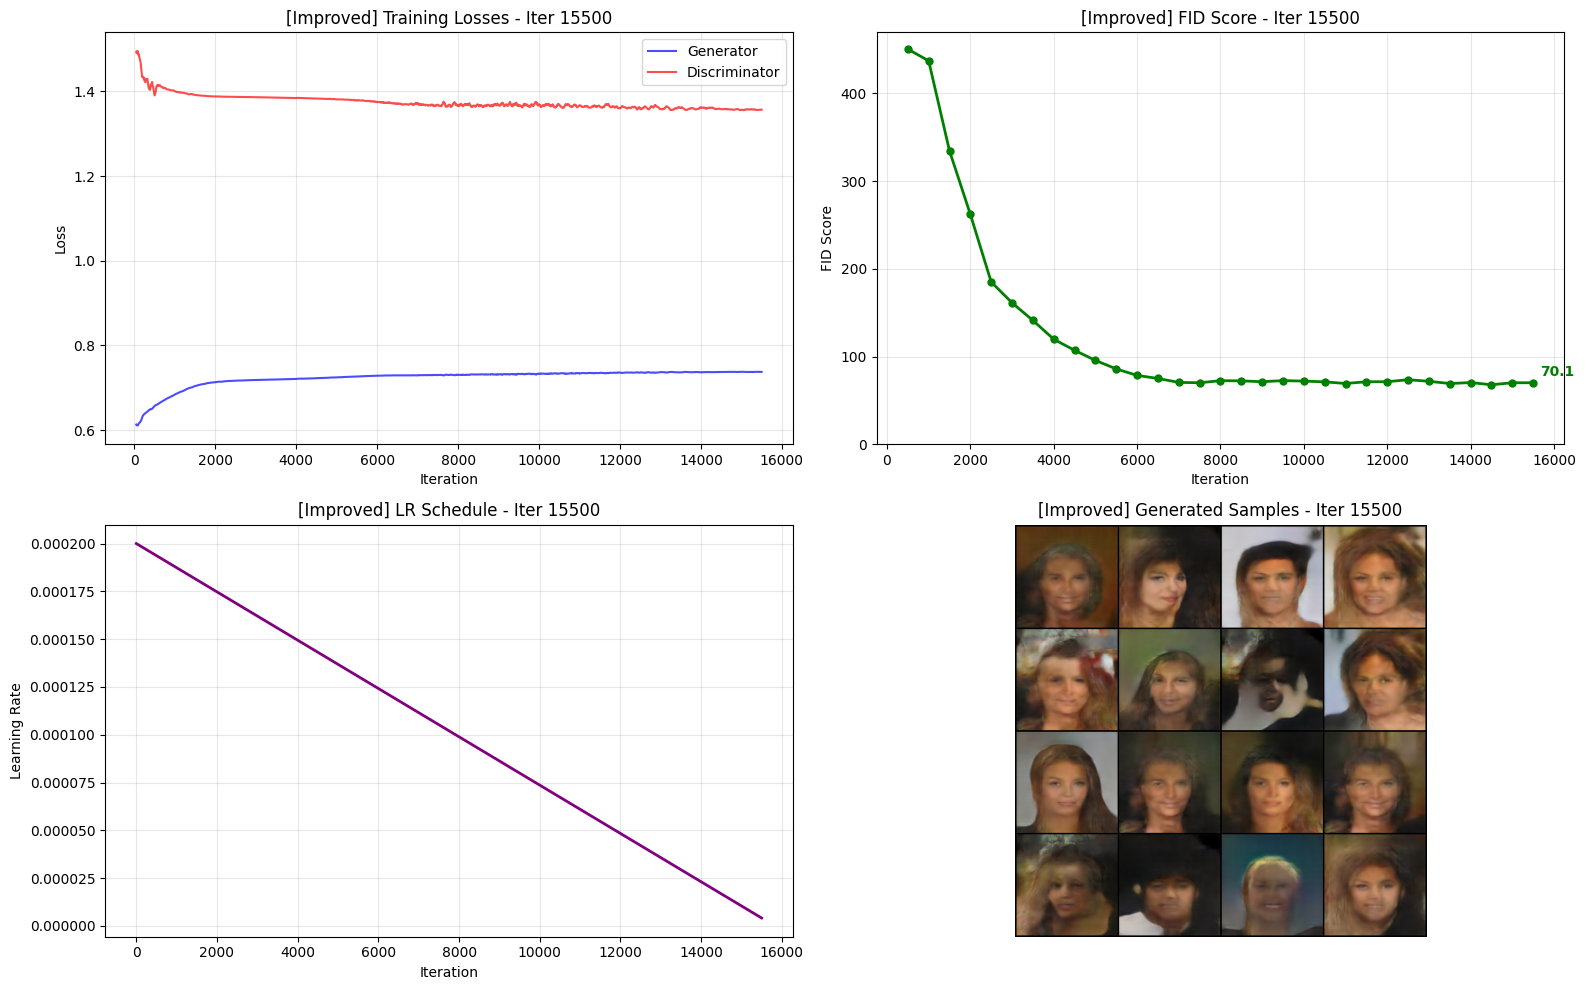

[Improved] Epoch 5/5:  90%|████████▉ | 2836/3166 [23:44<39:48,  7.24s/it, D_loss=1.3555, G_loss=0.7377, lr=0.000004]

[Improved] Iter 15500 | G: 0.7377 | D: 1.3555 | FID: 70.09 | LR: 0.000004


[Improved] Epoch 05/5 completed | Iter: 15830

[Improved] Training completed!
[Improved] Final FID: 70.09


In [23]:
from tqdm import tqdm

G_improved = Generator(latent_dim=100)
D_improved = Discriminator()

results_improved = train_gan(
    G=G_improved, 
    D=D_improved, 
    dataloader=dataloader, 
    epochs=5, 
    use_ema=True,
    ema_decay=0.999, 
    plot_interval=500, 
    model_name="Improved"
)